# 14: The Current Crisis, Diagnosed

**Business question**: On 17 September 2026, AirAsia and Capital A shares fell 21% and 18% after reports the Malaysian government was in contingency talks with Malaysia Airlines and Batik Air about absorbing AirAsia's domestic routes. CEO Tony Fernandes publicly disputed the widely-cited RM18.4 billion liabilities figure driving the panic, saying only a fraction of it is real near-term debt. Reading the actual filed balance sheet directly: is this a genuine solvency crisis, or a number that got amplified past what it means?

## Reconciling the disputed number

In [1]:
import pandas as pd
from IPython.display import Image

bs = pd.read_csv('../data/processed/balance_sheet_2q2026.csv', index_col='item')
cur_liab = bs.loc['Total current liabilities', 'rm_million']
cur_lease = bs.loc['Current lease liabilities', 'rm_million']
cur_assets = bs.loc['Total current assets', 'rm_million']
cash = bs.loc['Cash and bank balances', 'rm_million']

print(f"Headline current liabilities: RM{cur_liab:,.0f}m (this is the 'RM18.4bn' figure)")
print(f"Of which current lease liabilities: RM{cur_lease:,.0f}m ({cur_lease/cur_liab:.1%} of the total), matching Fernandes's 'RM2.8bn' figure")
print(f"Total current assets: RM{cur_assets:,.0f}m")
print(f"Working capital position: RM{cur_assets - cur_liab:,.0f}m (a deficit, the actual standard liquidity-stress metric)")
print(f"Cash on hand: RM{cash:,.0f}m")
bs

Headline current liabilities: RM18,412m (this is the 'RM18.4bn' figure)
Of which current lease liabilities: RM2,757m (15.0% of the total), matching Fernandes's 'RM2.8bn' figure
Total current assets: RM3,868m
Working capital position: RM-14,544m (a deficit, the actual standard liquidity-stress metric)
Cash on hand: RM954m


,rm_million
item,
Total current liabilities,18412
Current lease liabilities,2757
Trade and other payables,10260
Sales in advance,2089
Other current liabilities,3306
Total current assets,3868
Cash and bank balances,954
Total shareholders equity,483


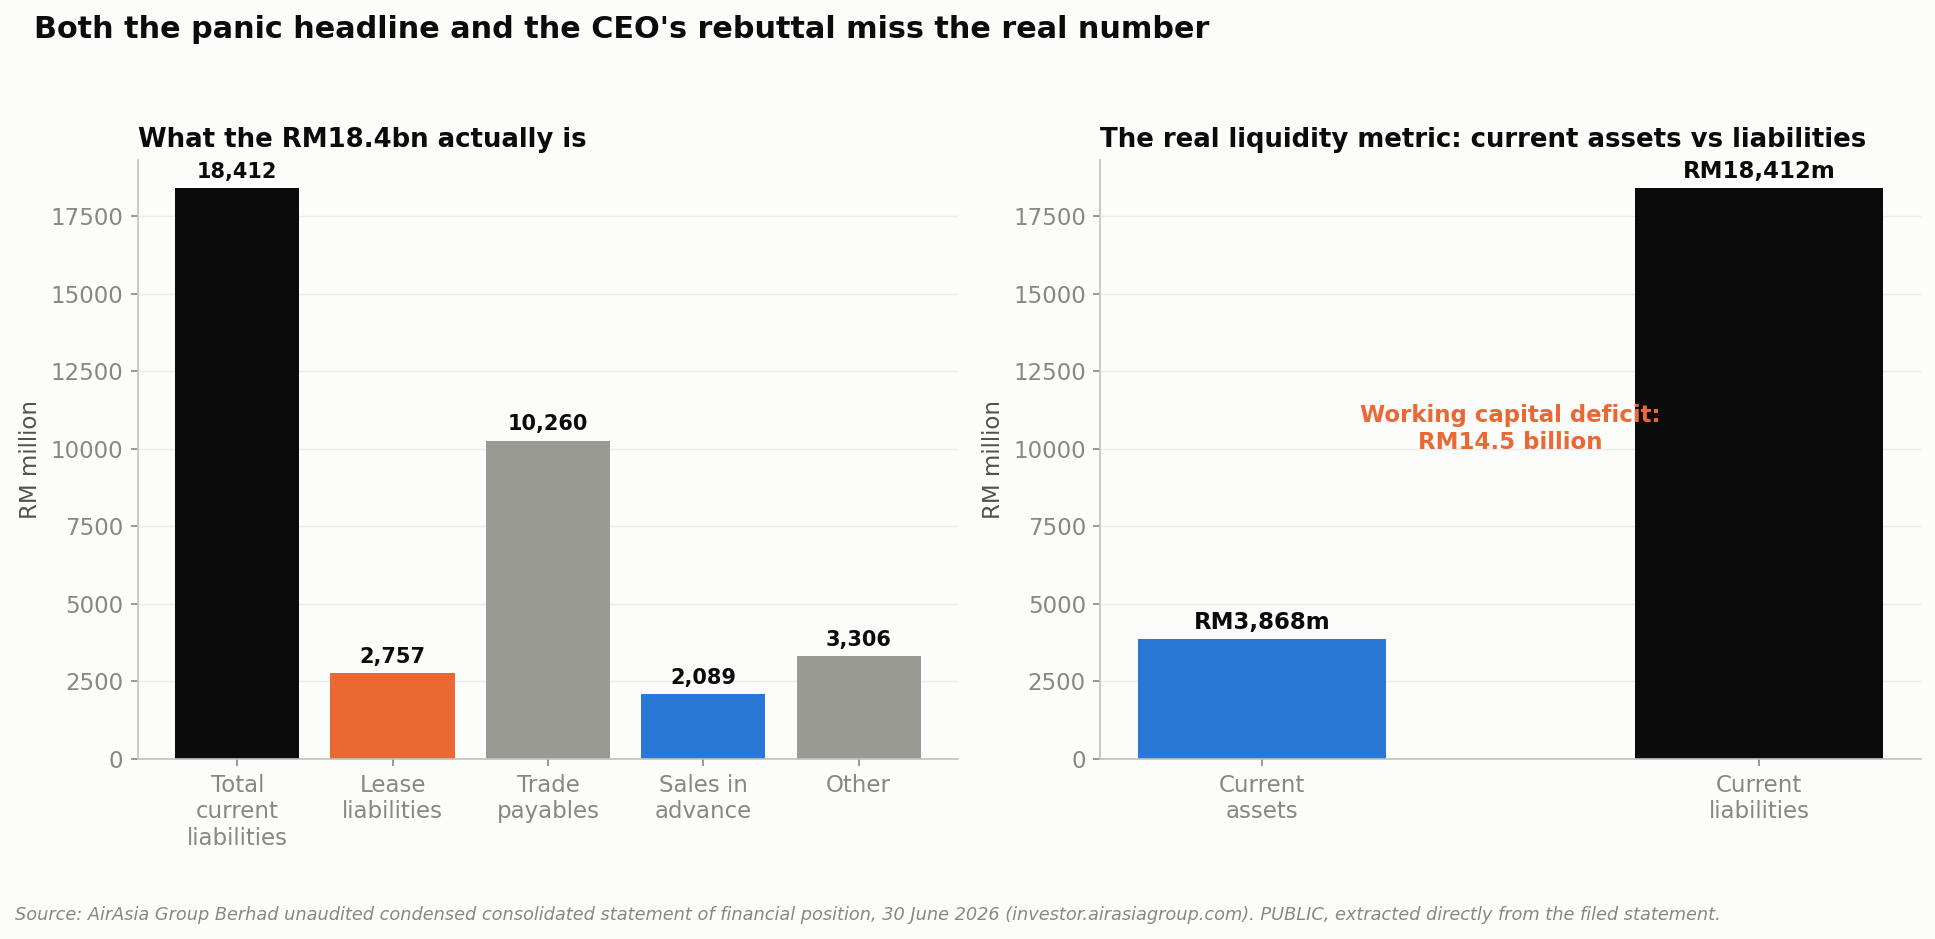

In [2]:
Image(filename='../outputs/figures/14_liability_reconciliation.png')

Both framings check out on their own narrow terms, and both are incomplete. The panic headline's RM18.4 billion is real: it is exactly the reported total current liabilities as of 30 June 2026, directly from AirAsia Group's filed balance sheet. **[PUBLIC]** Fernandes's rebuttal is also real: current lease liabilities are exactly RM2.76 billion, about 15% of that total. **[PUBLIC]**

But neither number mentioned is the one a credit analyst would actually reach for first: **current assets of only RM3.87 billion against RM18.41 billion of current liabilities**, a working capital deficit of **RM14.5 billion**. Roughly RM10.26 billion of the current liabilities is trade and other payables (money owed to suppliers, lessors, and vendors), a genuine, if less headline-grabbing, near-term obligation. A further RM2.09 billion is sales in advance (tickets already sold for future flights), which is not really distress risk at all; it converts to flown revenue rather than a cash outflow. Cash on hand is **RM954 million**. **[PUBLIC]**

## The honest diagnosis

The specific claim that spooked the market, "RM18.4 billion in liabilities" read as if it were all urgent near-term debt, was imprecise; a large share of it is ordinary trade payables and deferred ticket revenue, not distress-specific debt. The CEO's rebuttal correctly identifies this. But his response, framed narrowly around lease liabilities, does not address the underlying working-capital deficit, which is real, large, and is the metric that actually determines whether a company can meet its near-term obligations from what it currently holds. A RM14.5 billion shortfall against RM954 million in cash is a genuine liquidity stress signal, independent of how the RM18.4 billion gets sliced.

This connects directly to Notebook 5's finding: the 2Q26 operating loss (CASK exceeding RASK) was driven by the fuel price shock, not a broad cost-control failure. That supports treating this as a real but externally-triggered stress event rather than evidence of mismanagement, while still being a serious liquidity position that explains why the government is doing contingency planning.

## How urgent is it actually: a real burn-rate check

A working capital deficit is a snapshot. It doesn't say whether the gap is a three-week problem or a nine-month one. AirAsia Group's own filed cash flow statement makes that checkable directly.

In [3]:
cf = pd.read_csv('../data/processed/cash_flow_1h2026.csv', index_col='item')

op_outflow_6mo = cf.loc['Net cash used in operating activities', 'rm_million']
monthly_burn = op_outflow_6mo / 6
cash_end = cf.loc['Cash at end of period', 'rm_million']
runway_months = cash_end / abs(monthly_burn)

financing_raised = cf.loc[['Proceeds from issuance of shares', 'Proceeds from debentures', 'Proceeds from borrowings'], 'rm_million'].sum()
financing_repaid = cf.loc[['Repayment of borrowings', 'Repayment of debentures', 'Repayment of lease liabilities'], 'rm_million'].sum()

print(f"Net cash used in operating activities, 1H2026 (6 months): RM{op_outflow_6mo:,.1f}m")
print(f"Implied average monthly operating cash burn: RM{monthly_burn:,.1f}m")
print(f"Cash on hand at period end: RM{cash_end:,.1f}m -> roughly {runway_months:.1f} months of pure operating burn, all else equal")
print(f"\nSeparately, in the same 6 months, the Group raised RM{financing_raised:,.1f}m in new financing")
print(f"and repaid RM{abs(financing_repaid):,.1f}m of existing debt/lease obligations,")
print(f"a net financing inflow of RM{financing_raised + financing_repaid:,.1f}m.")

Net cash used in operating activities, 1H2026 (6 months): RM-581.6m
Implied average monthly operating cash burn: RM-96.9m
Cash on hand at period end: RM953.7m -> roughly 9.8 months of pure operating burn, all else equal

Separately, in the same 6 months, the Group raised RM2,809.1m in new financing
and repaid RM2,404.7m of existing debt/lease obligations,
a net financing inflow of RM404.4m.


Two things are true at once, and both matter for how urgent this actually is. First, on a pure operating-cash-burn basis, RM954 million in cash buys roughly **9-10 months** of runway if nothing else changed, meaningfully longer than the "weeks away from trouble" tone of the September panic coverage, though this is a rough average across a single half-year, not a forecast, and a second consecutive quarter like 2Q26 (higher fuel, a net loss) would burn faster than 1Q26 did. **[DERIVED, from the Group's own filed 1H2026 cash flow statement]**

Second, and more important: AirAsia Group is not sitting still against a fixed cash pile. In the same six months it raised **RM2.81 billion** in new financing (a private placement, new debentures, and new borrowings) while repaying **RM2.40 billion** of existing borrowings, debentures, and lease obligations, a net financing inflow of about **RM404 million**. The company is already actively rolling a large amount of debt in real time. The **USD1 billion plus RM700 million** it is separately seeking (Notebook 17) is incremental to this already-substantial ongoing activity, not a first attempt at addressing the gap. **[PUBLIC]**

Worth noting for urgency: the Group's most recent completed capital raise, a RM1.0 billion private placement announced back in July 2024, has already been **100% utilised** as of this report, split between working capital for the enlarged aviation group (RM954.6 million) and deal expenses (RM45.4 million). There is no unspent buffer sitting from that earlier raise; the new financing being sought now would be genuinely new money, not a top-up of something already in the bank. **[PUBLIC, AirAsia Group 2Q26 Quarterly Announcement, Note 32]**

## Explain It Simply

When news broke that the government was quietly planning for other airlines to take over AirAsia's routes, everyone pointed to AirAsia owing RM18.4 billion as proof of a crisis. AirAsia's CEO pushed back, saying most of that isn't real debt, only RM2.8 billion of it is loans on planes. Both of them are technically right and both are leaving something out. The RM18.4 billion is real, but a lot of it is normal business bills and pre-sold tickets, not emergency debt. But focusing only on the lease liabilities misses the bigger, plainer problem: AirAsia only has RM3.9 billion in cash and short-term assets to cover RM18.4 billion in short-term bills, a RM14.5 billion gap, with less than RM1 billion in the bank. That gap is the real number to worry about, and neither the panic headline nor the CEO's rebuttal said it plainly.

## Glossary

- **Working capital deficit**: when current liabilities (due within 12 months) exceed current assets, a standard signal of near-term liquidity stress.
- **Trade and other payables**: amounts owed to suppliers, vendors, and lessors for goods/services already received.
- **Sales in advance**: cash already collected for tickets on flights not yet flown, a liability on the books but not a distress signal in the way debt is.
- **Cash burn rate**: the pace at which a company's cash balance is depleted by ongoing operations, usually expressed per month; tells you how much runway a fixed cash balance actually buys.

## Why Is This Happening?

**Why would a company with a genuine RM14.5 billion working capital deficit still be operating normally, still flying, still selling tickets?** Airlines routinely run negative working capital as a structural feature of the business, since they collect cash for tickets well before they incur the cost of flying the passenger (the RM2.09 billion in sales in advance is part of this). A working capital deficit is a red flag when it is large and growing without offsetting cash generation; it is closer to normal, if uncomfortable, in an industry where prepaid revenue is standard. What makes this instance worth the government's attention is the combination of the deficit's scale (RM14.5 billion against under RM1 billion cash) with an operating loss in the same quarter (Notebook 5), removing the cushion that ordinarily lets airlines carry negative working capital indefinitely.

---
**Sources**: AirAsia Group Berhad unaudited condensed consolidated statement of financial position and cash flow statement, 30 June 2026 (investor.airasiagroup.com/misc/qr/Quarterly_Announcement_2Q2026.pdf), Notes 27 and 32, extracted directly by this project; [BigGo Finance: AirAsia fell 21% as the government plans for its routes](https://finance.biggo.com/news/5dc89b5f-6188-4957-8c94-0c94462ec458); [Dr Wealth: how bad is it really](https://drwealth.com/airasia-fell-21-as-the-government-plans-for-its-routes-how-bad-is-it-really/). All balance sheet and cash flow figures **PUBLIC**, extracted directly from the company's own filed statement; the reconciliation, "working capital deficit," and burn-rate/runway framing are this project's own analysis, classified **DERIVED**.